# Wizualizacja danych z Pandas, Matplotlib i Seaborn

## 1. Import bibliotek

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Ustawienia dla czytelności wykresów
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")  # Styl seaborn

## 2. Przygotowanie danych

In [2]:
data = {
    "wojewodztwo": ["łódzkie", "łódzkie", "łódzkie", "łódzkie", "łódzkie",
                     "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie", "mazowieckie"],
    "rok": [2000, 2005, 2010, 2015, 2020,
            2000, 2005, 2010, 2015, 2020],
    "populacja_mln": [2.67, 2.59, 2.54, 2.49, 2.44,
                      5.07, 5.14, 5.24, 5.35, 5.42]
}
df_woj = pd.DataFrame(data)
df_woj.head(10)

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44
5,mazowieckie,2000,5.07
6,mazowieckie,2005,5.14
7,mazowieckie,2010,5.24
8,mazowieckie,2015,5.35
9,mazowieckie,2020,5.42


In [3]:
df_woj.keys()

Index(['wojewodztwo', 'rok', 'populacja_mln'], dtype='object')

In [4]:
# Filtracja danych dla każdego województwa
mazowieckie = df_woj[df_woj["wojewodztwo"] == "mazowieckie"]
lodzkie = df_woj[df_woj["wojewodztwo"] == "łódzkie"]

In [5]:
lodzkie

,wojewodztwo,rok,populacja_mln
0,łódzkie,2000,2.67
1,łódzkie,2005,2.59
2,łódzkie,2010,2.54
3,łódzkie,2015,2.49
4,łódzkie,2020,2.44


## 3. WYKRES LINIOWY (Line Plot)

**Zastosowanie:** Przedstawianie zmian w czasie, trendów

(1999.0, 2021.0)

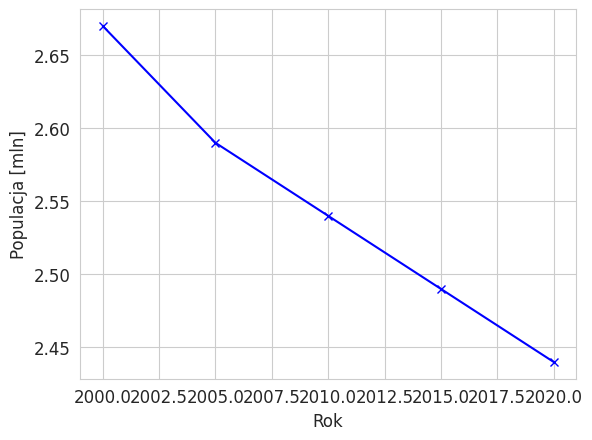

In [6]:
plt.plot(lodzkie["rok"], lodzkie["populacja_mln"], "bx-")
plt.xlabel("Rok")
plt.ylabel("Populacja [mln]")
plt.xlim([1999, 2021])

Text(0, 0.5, 'pop [mln]')

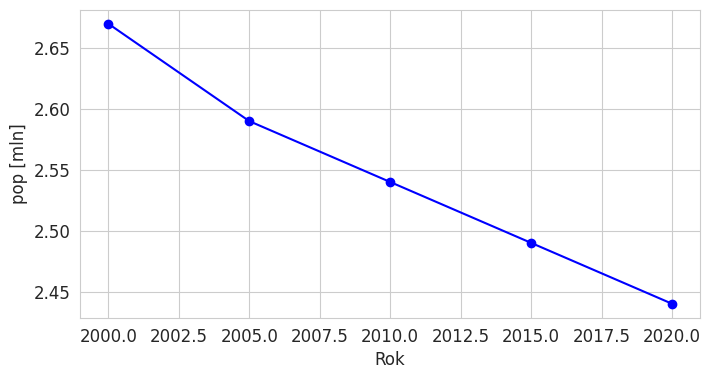

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax.set_xlabel("Rok")
ax.set_ylabel("pop [mln]")

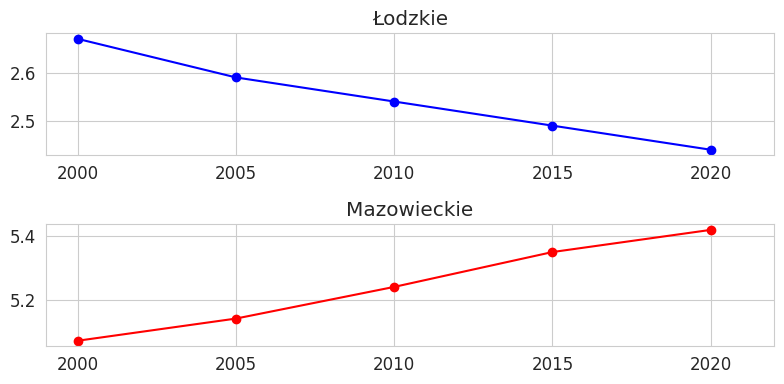

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(8, 4))
ax[0].plot(lodzkie["rok"], lodzkie["populacja_mln"], 'bo-')
ax[0].set_title("Łodzkie")
ax[1].plot(mazowieckie["rok"], mazowieckie["populacja_mln"], 'ro-')
ax[0].set_xlim([1999, 2022])
ax[1].set_xlim([1999, 2022])
ax[1].set_title("Mazowieckie")
plt.tight_layout()

### Bezpośrednio `plot` na pandas DataFrame

<Axes: xlabel='rok'>

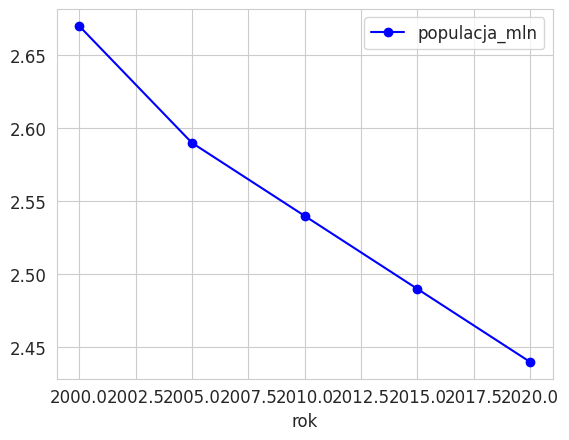

In [9]:
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue")

<Axes: xlabel='rok'>

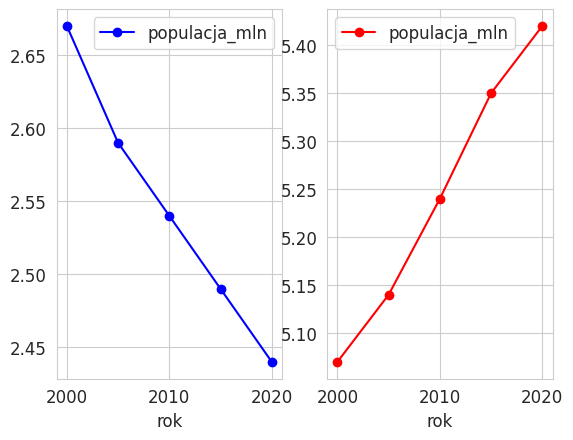

In [10]:
fig, ax = plt.subplots(1, 2)
lodzkie.plot(x="rok", y="populacja_mln", marker="o", color="blue", ax=ax[0])
mazowieckie.plot(x="rok", y="populacja_mln", marker="o", color="red", ax=ax[1])

## 4. WYKRES PUNKTOWY (Scatter Plot)

 **Zastosowanie:** Pokazywanie relacji między dwiema zmiennymi

In [11]:
# Generowanie dodatkowych danych dla scatter plot
np.random.seed(42)
scatter_data = pd.DataFrame({
    'temperatura': np.random.uniform(15, 35, 1500),
    'sprzedaz_lodow': np.random.uniform(50, 300, 1500)
})
# Dodajemy korelację
scatter_data['sprzedaz_lodow'] = scatter_data['sprzedaz_lodow'] + scatter_data['temperatura'] * 5

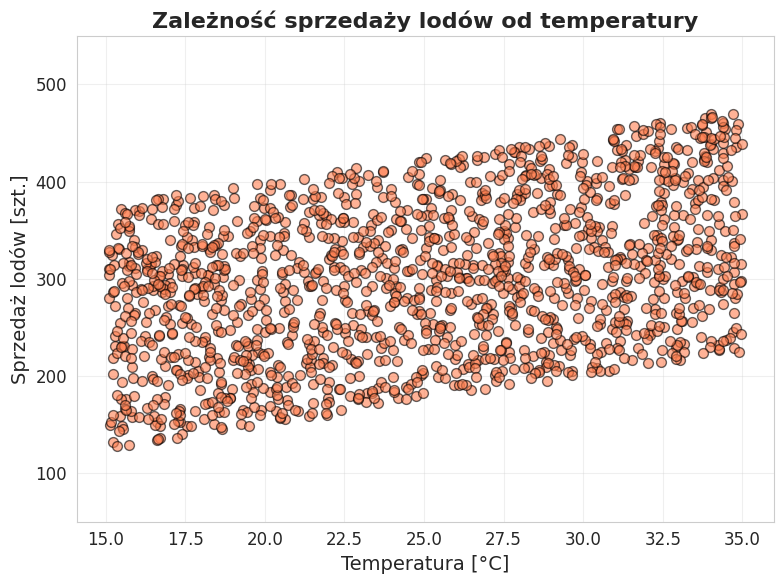

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(scatter_data['temperatura'], scatter_data['sprzedaz_lodow'],
            s=50, alpha=0.6, c='coral', edgecolors='black', linewidth=1)

plt.title('Zależność sprzedaży lodów od temperatury', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. WYKRES SŁUPKOWY (Bar Plot)

 **Zastosowanie:** Porównywanie wartości między kategoriami

In [13]:
# Dane dla wykresu słupkowego - populacja miast w dwóch różnych latach
miasta_data = pd.DataFrame({
    'miasto': ['Warszawa', 'Kraków', 'Łódź', 'Wrocław', 'Poznań'],
    'populacja_2022': [1795, 800, 670, 672, 545],
    'populacja_2010': [1700, 757, 730, 632, 550]
})

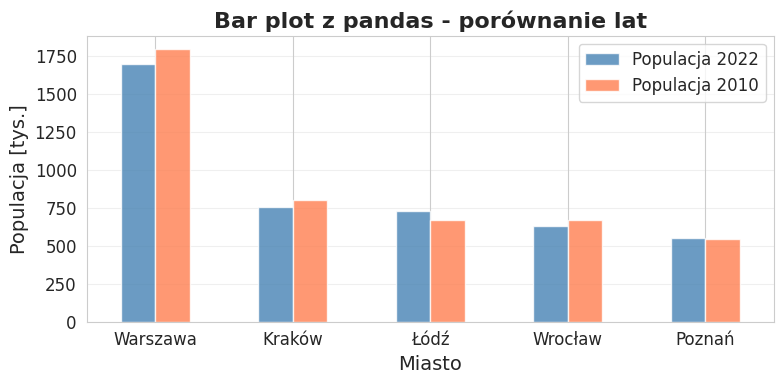

In [14]:
# Bar plot - Pandas

miasta_data.plot.bar(x='miasto', y=['populacja_2010', 'populacja_2022'],
                     figsize=(8, 4), color=['steelblue', 'coral'], alpha=0.8)
plt.title('Bar plot z pandas - porównanie lat', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Populacja [tys.]', fontsize=14)
plt.legend(['Populacja 2022', 'Populacja 2010'], fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Jak to zrobić z Seaborn?

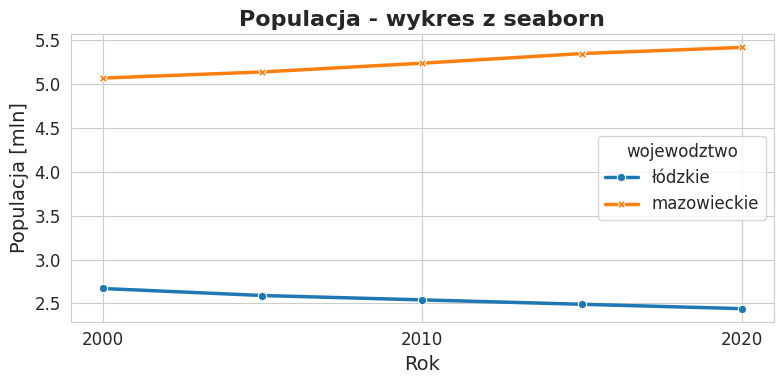

In [15]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=df_woj, x='rok', y='populacja_mln', hue='wojewodztwo',
             style='wojewodztwo', markers=True, dashes=False, linewidth=2.5)

plt.title('Populacja - wykres z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Rok', fontsize=14)
plt.ylabel('Populacja [mln]', fontsize=14)
plt.xticks([2000, 2010, 2020])
plt.tight_layout()
plt.show()

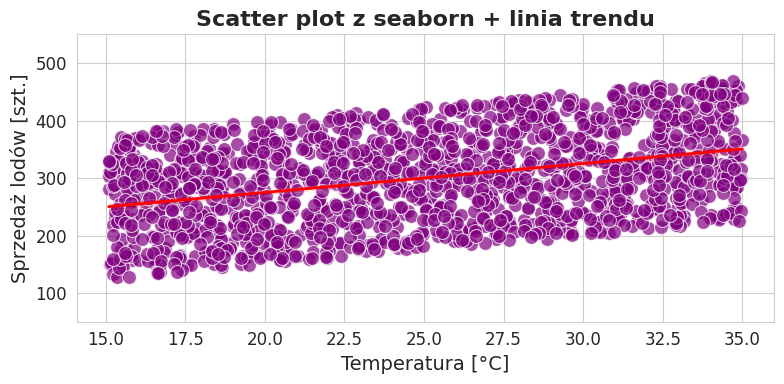

In [16]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
                s=100, alpha=0.7, color='purple')
sns.regplot(data=scatter_data, x='temperatura', y='sprzedaz_lodow',
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('Scatter plot z seaborn + linia trendu', fontsize=16, fontweight='bold')
plt.xlabel('Temperatura [°C]', fontsize=14)
plt.ylabel('Sprzedaż lodów [szt.]', fontsize=14)
plt.ylim([50, 550])
plt.tight_layout()
plt.show()

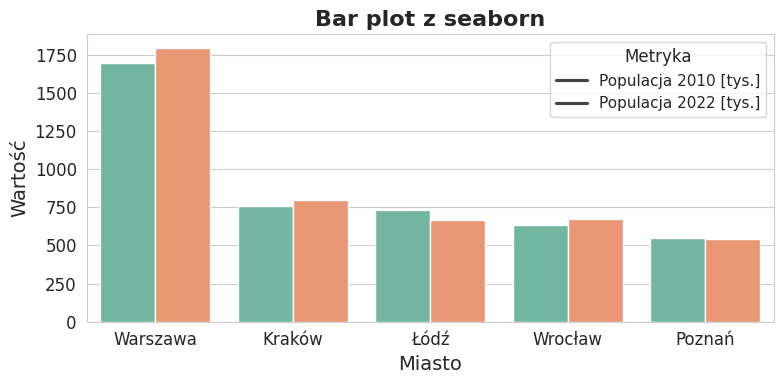

In [17]:
# Bar plot - Seaborn

# Przekształcenie danych do formatu długiego (long format)
miasta_long = pd.melt(miasta_data, id_vars=['miasto'],
                      value_vars=['populacja_2010', 'populacja_2022'],
                      var_name='Typ', value_name='Wartość')

plt.figure(figsize=(8, 4))
sns.barplot(data=miasta_long, x='miasto', y='Wartość', hue='Typ', palette='Set2')
plt.title('Bar plot z seaborn', fontsize=16, fontweight='bold')
plt.xlabel('Miasto', fontsize=14)
plt.ylabel('Wartość', fontsize=14)
plt.legend(title='Metryka', labels=['Populacja 2010 [tys.]', 'Populacja 2022 [tys.]'], fontsize=11)
plt.tight_layout()
plt.show()

# ZADANIA


## Zadanie 1: Podstawy DataFrame i wykres liniowy

**Dane:** Liczba mieszkańców Warszawy i Łodzi w wybranych latach:

| Rok  | Warszawa  | Łódź      |
|------|-----------|-----------|
| 2002 | 1672000   | 789318    |
| 2011 | 1707000   | 728892    |
| 2015 | 1740000   | 700982    |
| 2022 | 1795000   | 670642    |

**Polecenia:**
1. Utwórz słownik z powyższymi danymi
2. Stwórz DataFrame z tego słownika
5. **Stwórz wykres liniowy** pokazujący zmiany populacji obu miast w czasie
   - Użyj różnych kolorów i markerów dla każdego miasta
    - Dodaj tytuł, opisy osi i legendę
    - Wypróbuj wszystkie 3 metody (matplotlib, pandas, seaborn)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. i 2. Tworzenie słownika i DataFrame
dane_miasta = {
    'Rok': [2002, 2011, 2015, 2022],
    'Warszawa': [1672000, 1707000, 1740000, 1795000],
    'Łódź': [789318, 728892, 700982, 670642]
}

df_zad1 = pd.DataFrame(dane_miasta)
print(df_zad1)

    Rok  Warszawa    Łódź
0  2002   1672000  789318
1  2011   1707000  728892
2  2015   1740000  700982
3  2022   1795000  670642


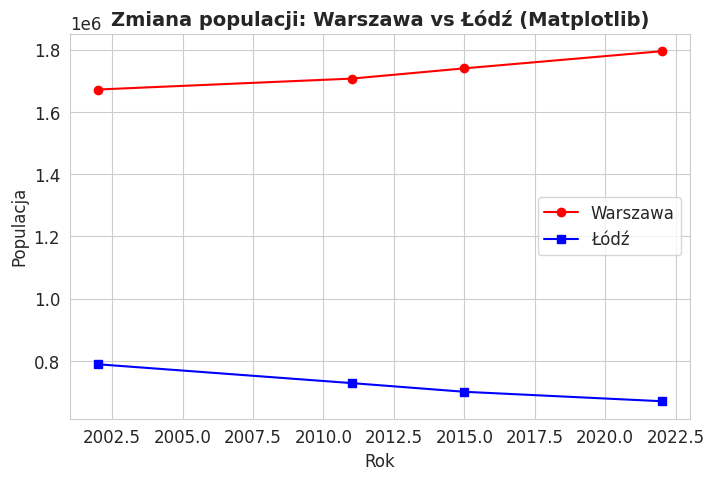

In [21]:
# Matplotlib
plt.figure(figsize=(8, 5))

plt.plot(df_zad1['Rok'], df_zad1['Warszawa'], marker='o', color='red', label='Warszawa')
plt.plot(df_zad1['Rok'], df_zad1['Łódź'], marker='s', color='blue', label='Łódź')

plt.title('Zmiana populacji: Warszawa vs Łódź (Matplotlib)', fontsize=14, fontweight='bold')
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Populacja', fontsize=12)
plt.legend()
plt.show()

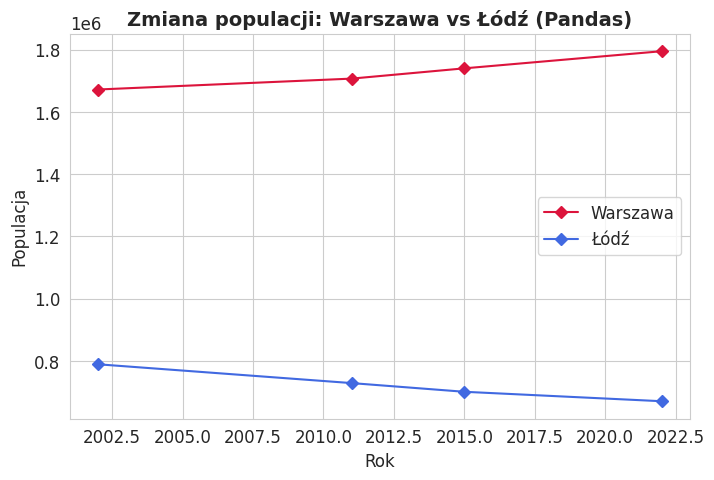

In [22]:
# Pandas
df_zad1.plot(
    x='Rok',
    y=['Warszawa', 'Łódź'],
    kind='line',
    marker='D',
    color=['crimson', 'royalblue'],
    figsize=(8, 5))

plt.title('Zmiana populacji: Warszawa vs Łódź (Pandas)', fontsize=14, fontweight='bold')
plt.xlabel('Rok')
plt.ylabel('Populacja')
plt.show()

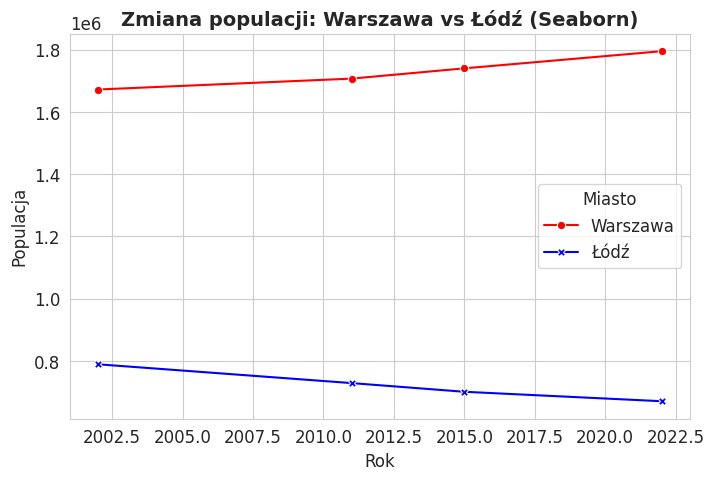

In [23]:
# Seaborn
df_long = pd.melt(
    df_zad1,
    id_vars=['Rok'],
    value_vars=['Warszawa', 'Łódź'],
    var_name='Miasto',
    value_name='Populacja')

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df_long,
    x='Rok',
    y='Populacja',
    hue='Miasto',
    style='Miasto',
    markers=True,
    dashes=False,
    palette=['red', 'blue'])

plt.title('Zmiana populacji: Warszawa vs Łódź (Seaborn)', fontsize=14, fontweight='bold')
plt.xlabel('Rok')
plt.ylabel('Populacja')
plt.show()

## Zadanie 2: Analiza danych o pojazdach w Łodzi

Dane pochodzą z portalu otwartych danych miasta Łodzi: https://otwarte.miasto.lodz.pl/transport_komunikacja/

### Do zrobienia:

1. **Wczytaj plik** `Pojazdy-ogolem-w-Lodzi.csv`

2. **Utwórz wykres punktowy** pokazujący zmianę liczby:
   - samochody osobowe
   - autobusy ogółem
   
   na przestrzeni lat. Dla każdego typu zrób osobny wykres.

3. **Utwórz wykres słupkowy** dla roku 2020 przedstawiający liczbę:
   - autobusów
   - samochodów osobowych
   - samochodów ciężarowych
   - motocykli

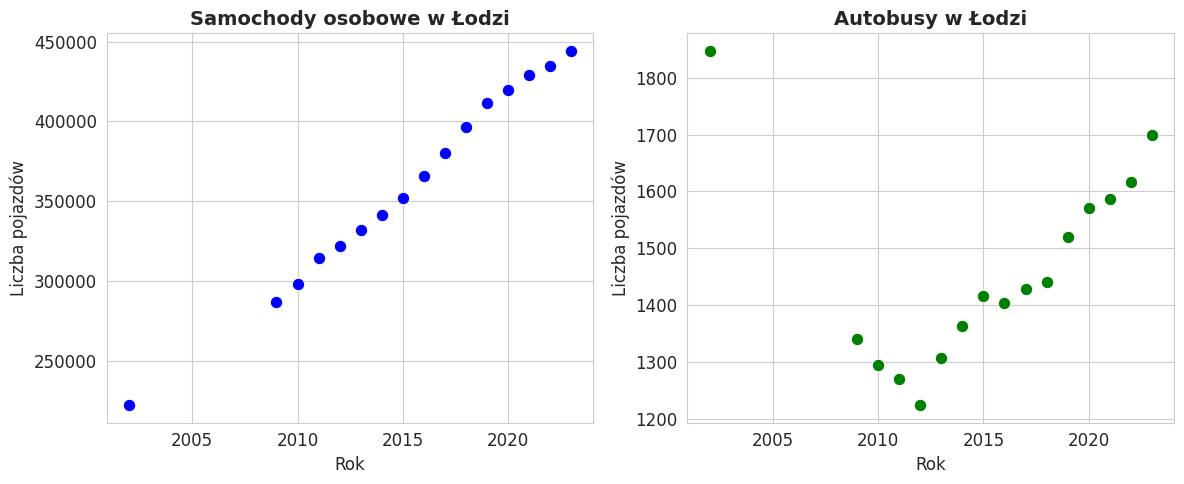

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Wczytujemy plik
df_pojazdy = pd.read_csv('pojazdy-ogoem-w-odzi.csv', sep=';')

# Filtrujemy dane dla konkretnych pojazdów
osobowe = df_pojazdy[df_pojazdy['zmienne'] == 'samochody osobowe']
autobusy = df_pojazdy[df_pojazdy['zmienne'] == 'autobusy ogółem']

# Ustawiamy rozmiar obrazka i robimy siatkę (1 wiersz, 2 kolumny)
plt.figure(figsize=(12, 5))

# WYKRES 1: Samochody osobowe (lewa strona)
plt.subplot(1, 2, 1)
sns.scatterplot(data=osobowe, x='rok', y='wartość', color='blue', s=80)
plt.title('Samochody osobowe w Łodzi', fontsize=14, fontweight='bold')
plt.xlabel('Rok')
plt.ylabel('Liczba pojazdów')

# WYKRES 2: Autobusy ogółem (prawa strona)
plt.subplot(1, 2, 2)
sns.scatterplot(data=autobusy, x='rok', y='wartość', color='green', s=80)
plt.title('Autobusy w Łodzi', fontsize=14, fontweight='bold')
plt.xlabel('Rok')
plt.ylabel('Liczba pojazdów')

plt.tight_layout()
plt.show()

/tmp/ipykernel_307/4061681056.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dane_2020, x='zmienne', y='wartość', palette='viridis')


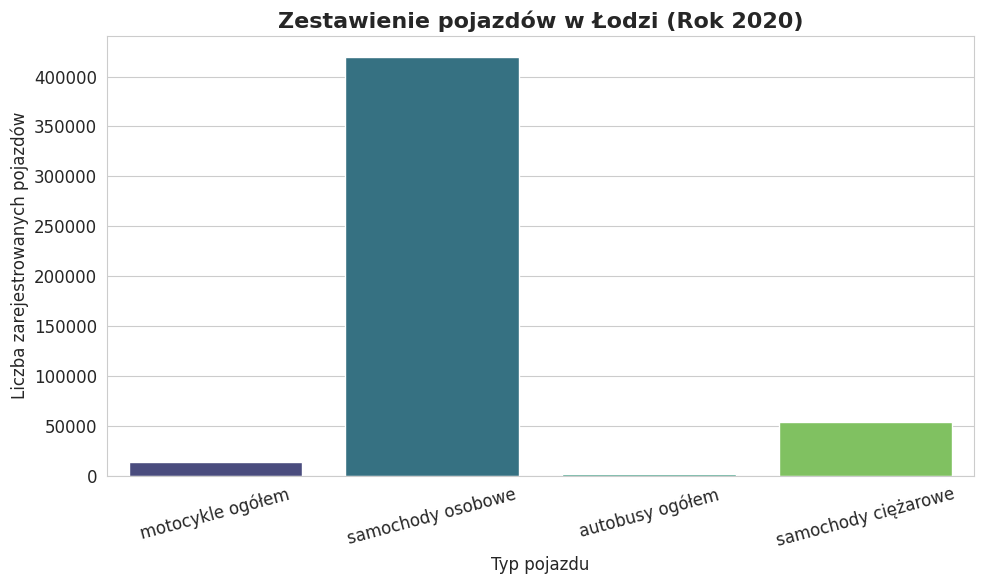

In [26]:
# Filtrujemy tabelę tylko dla roku 2020
dane_2020 = df_pojazdy[df_pojazdy['rok'] == 2020]

# Rysujemy wykres słupkowy prosto z przefiltrowanych danych
plt.figure(figsize=(10, 6))

# X to kategoria z pliku ('zmienne'), Y to liczba z pliku ('wartość')
sns.barplot(data=dane_2020, x='zmienne', y='wartość', palette='viridis')

plt.title('Zestawienie pojazdów w Łodzi (Rok 2020)', fontsize=16, fontweight='bold')
plt.xlabel('Typ pojazdu', fontsize=12)
plt.ylabel('Liczba zarejestrowanych pojazdów', fontsize=12)

# Delikatnie obracamy podpisy osi X, bo nazwy są dość długie
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()